# 07_RQ7_Final_Recommendation
Objective and methodology.

# ============================================
# RQ7: Final Model Recommendation
# ============================================

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs('outputs', exist_ok=True)


# ============================================
# 1. Create Decision Matrix (based on RQ2–RQ6)
# ============================================

In [6]:
data = {
    "Criteria": [
        "Predictive Performance",
        "Interpretability",
        "Robustness",
        "Computational Cost",
        "Deployment Suitability"
    ],
    
    "Logistic Regression": ["Medium", "High", "Medium", "Low", "High"],
    "Random Forest": ["High", "Medium", "High", "Medium", "High"],
    "XGBoost": ["Very High", "Low", "High", "High", "Medium"]
}

df = pd.DataFrame(data)

print("\nDecision Matrix:\n")
print(df)

# Save table
df.to_csv("RQ7_outputs/RQ7_Decision_Matrix.csv", index=False)


Decision Matrix:

                 Criteria Logistic Regression Random Forest    XGBoost
0  Predictive Performance              Medium          High  Very High
1        Interpretability                High        Medium        Low
2              Robustness              Medium          High       High
3      Computational Cost                 Low        Medium       High
4  Deployment Suitability                High          High     Medium


# ============================================
# 2. Visualization (Radar Chart)
# ============================================

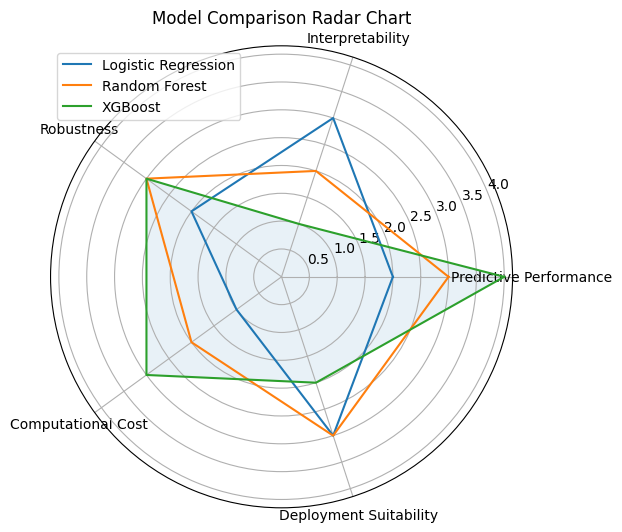

In [7]:
# Convert qualitative → numeric for plotting
score_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Very High": 4
}

df_plot = df.copy()

for col in df.columns[1:]:
    df_plot[col] = df_plot[col].map(score_map)

# Radar setup
labels = df_plot["Criteria"]
values_lr = df_plot["Logistic Regression"].tolist()
values_rf = df_plot["Random Forest"].tolist()
values_xgb = df_plot["XGBoost"].tolist()

# Close the loop
values_lr += values_lr[:1]
values_rf += values_rf[:1]
values_xgb += values_xgb[:1]

import numpy as np
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, values_lr, label="Logistic Regression")
ax.plot(angles, values_rf, label="Random Forest")
ax.plot(angles, values_xgb, label="XGBoost")

ax.fill(angles, values_xgb, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Model Comparison Radar Chart")
plt.legend()

plt.savefig("RQ7_outputs/RQ7_Radar_Chart.pdf")
plt.show()